In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)

from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

/Users/yadagirimallipeddi/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
Weekly = load_data('Weekly')
Weekly



,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


In [3]:
Weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [4]:
Weekly['Direction'].value_counts()

Direction
Up      605
Down    484
Name: count, dtype: int64

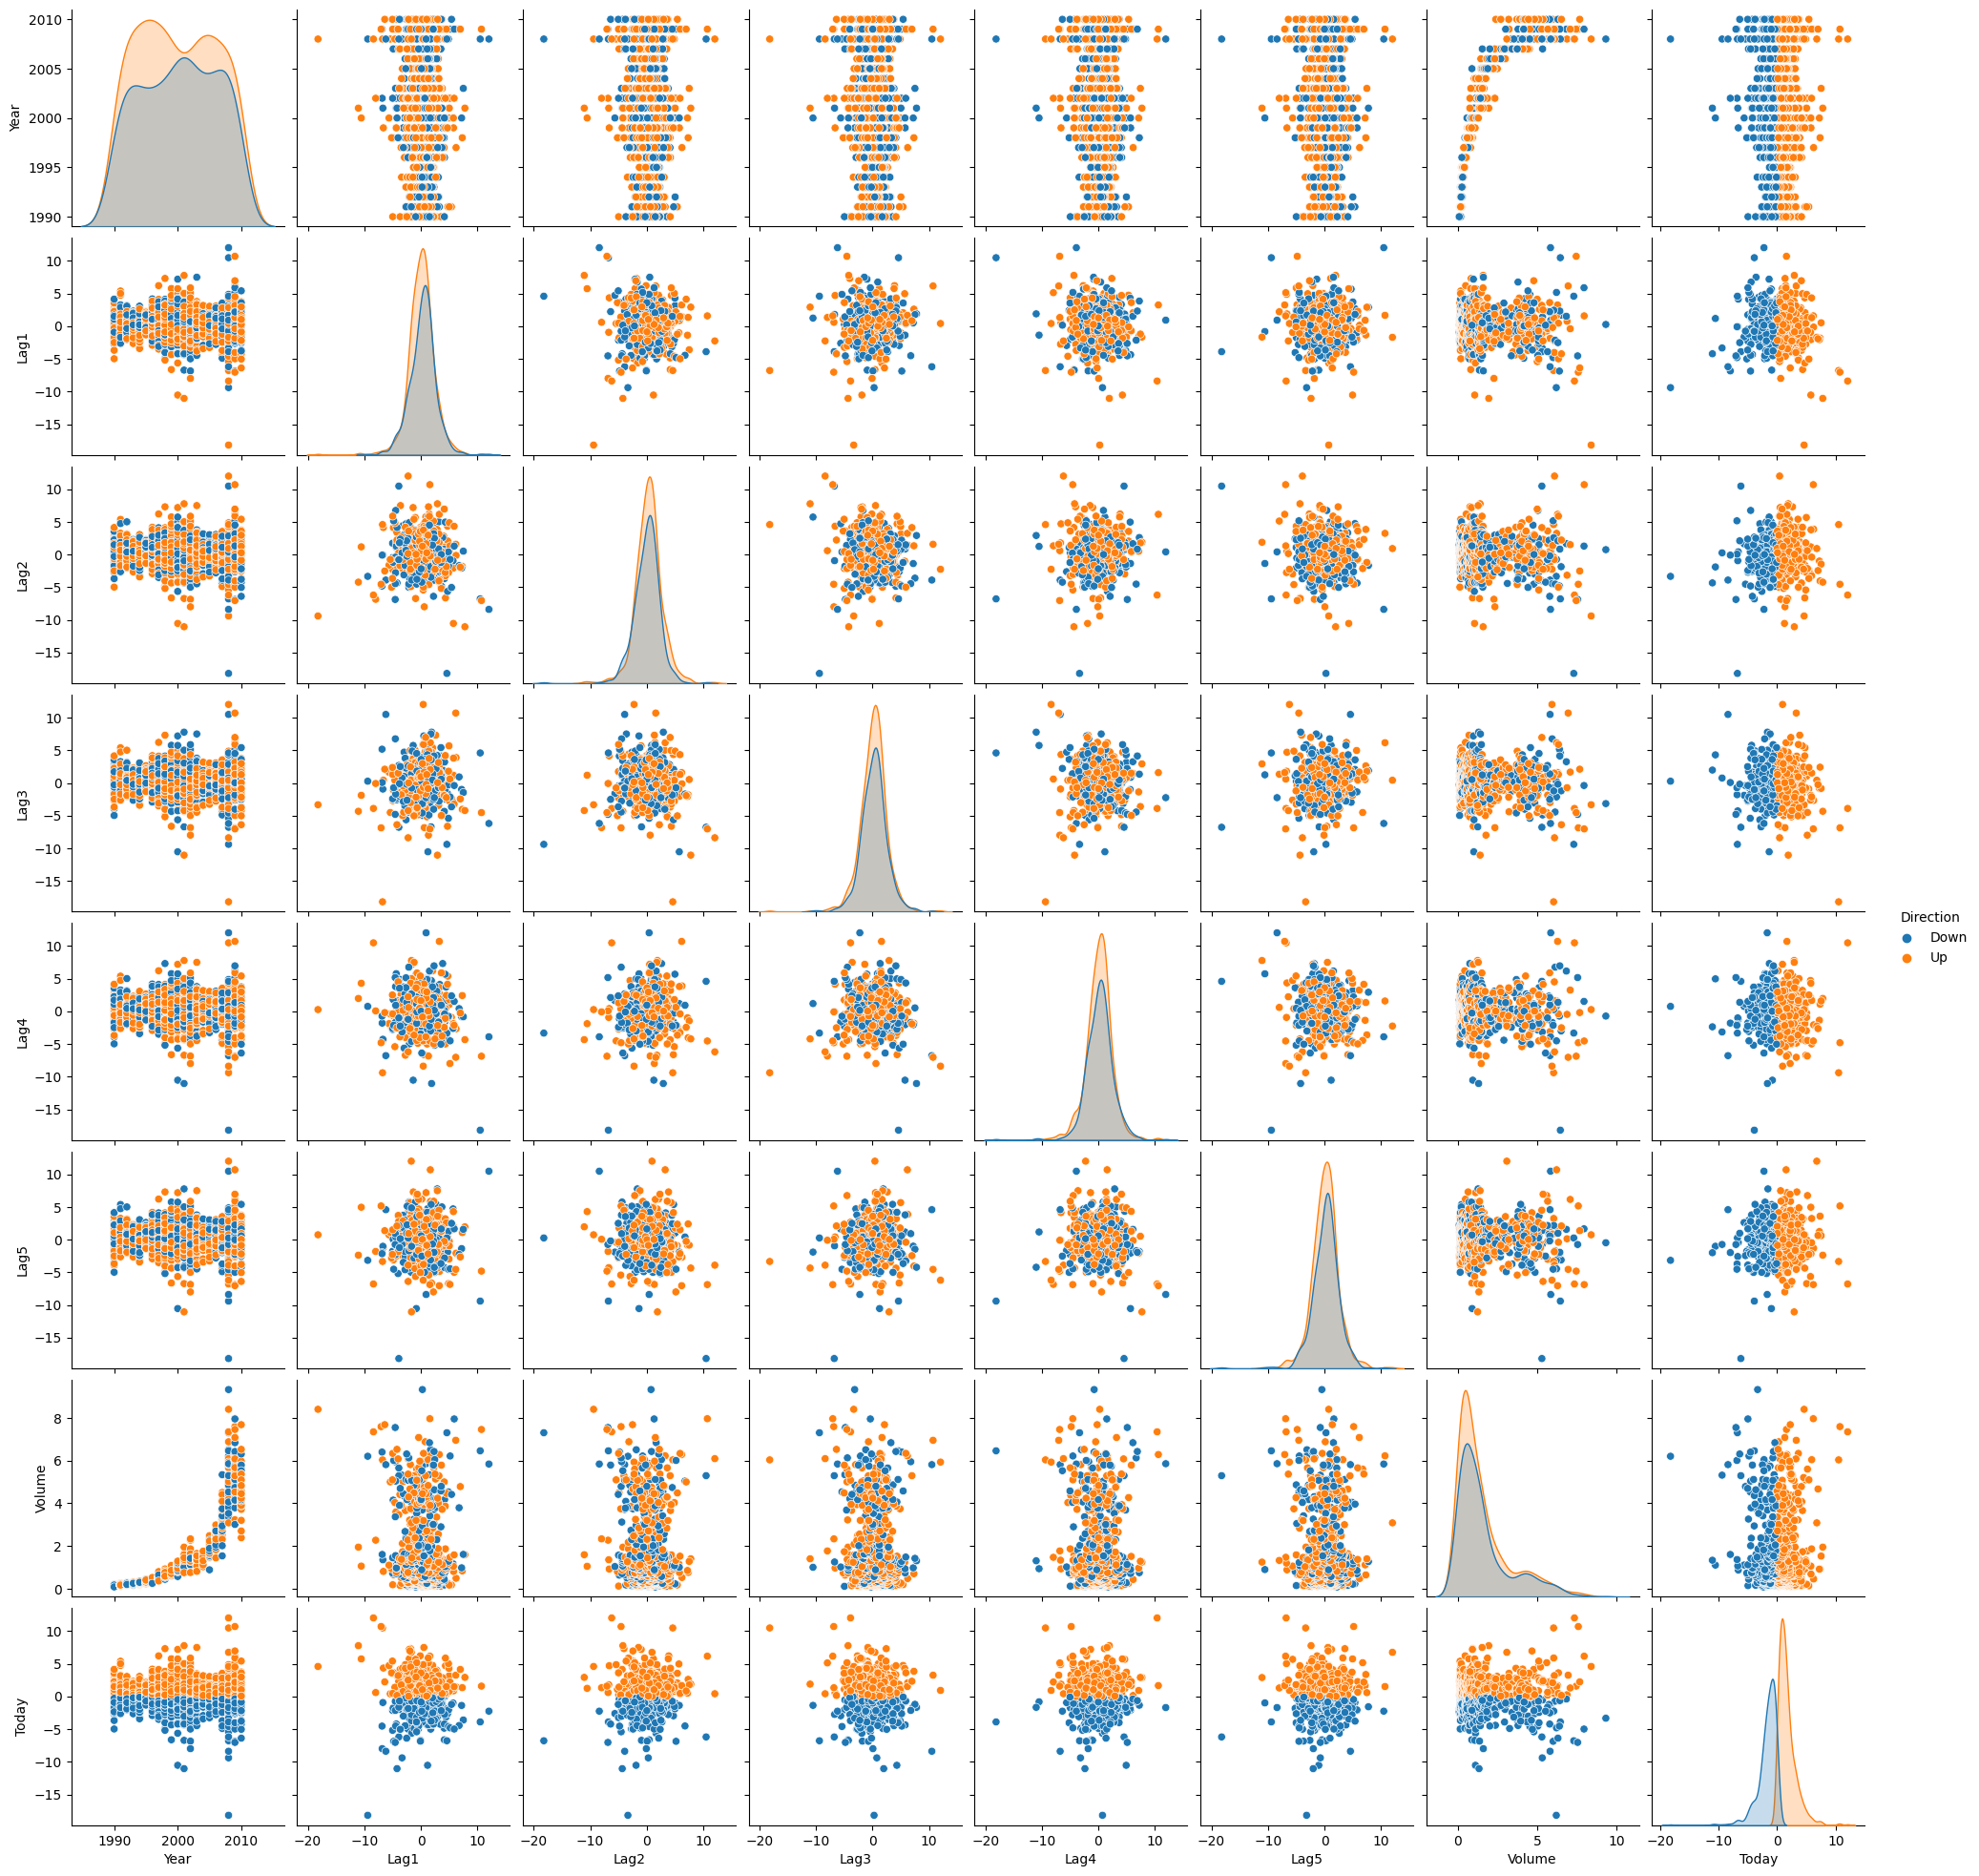

In [5]:
sns.pairplot(Weekly, hue = "Direction");

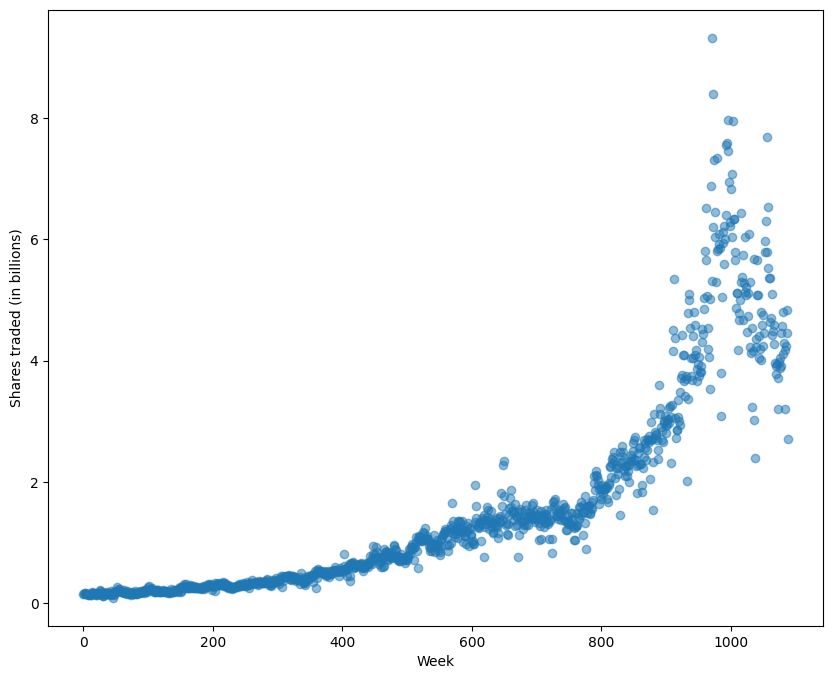

In [6]:
fig = plt.figure(figsize = (10, 8))
ax = plt.axes()
ax.scatter(x = Weekly.index, y = Weekly["Volume"], alpha = 0.5)
ax.set(xlabel = "Week", ylabel = "Shares traded (in billions)");

In [7]:
Weekly.index

RangeIndex(start=0, stop=1089, step=1)

In [8]:
allvars = Weekly.columns.drop(['Today', 'Direction', 'Year'])
X = sm.add_constant(Weekly[allvars], prepend=True)
#y = (Weekly["Direction"] == "Up").astype("int64")
y = Weekly.Direction == 'Up'
glm = sm.GLM(y,X,family=sm.families.Binomial())
#glm=sm.Logit(y, X)
results = glm.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1082
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.18
Date:                Mon, 17 Mar 2025   Deviance:                       1486.4
Time:                        12:22:24   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.009000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.026     -1.563      0.118      -0.093       0.010
Lag2           0.0584      0.027      2.175      0.030       0.006       0.111
Lag3          -0.0161      0.027     -0.602      0.547      -0.068       0.036
Lag4          -0.0278      0.026     -1.050      0.294      -0.080       0.024
Lag5          -0.0145      0.026     -0.549      0.583      -0.066       0.037
Volume        -0.0227      0.037     -0.616      0.538      -0.095       0.050
==============================================================================
"""

In [9]:
endog = (Weekly["Direction"] == "Up").astype("int64")
exog = sm.add_constant(Weekly.drop(columns = ["Direction", "Year", "Today"]))
logit_mod = sm.Logit(endog, exog)
logit_res = logit_mod.fit()
print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Mon, 17 Mar 2025   Pseudo R-squ.:                0.006580
Time:                        12:22:24   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

In [10]:
probs = results.predict()
labels = np.array(['Down']*1089)
labels[probs>0.5] = "Up"
confusion_table(labels, Weekly.Direction)

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [11]:
training=(Weekly.Year<2009)
X_train = sm.add_constant(Weekly.loc[training,'Lag2'], prepend=True)
y_train=(Weekly.loc[training, "Direction"] == "Up").astype("int64")
#y = train.Direction == 'Up'
glm = sm.GLM(y_train,X_train,family=sm.families.Binomial())
#glm=sm.Logit(y, X)
results = glm.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Direction   No. Observations:                  985
Model:                            GLM   Df Residuals:                      983
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -675.27
Date:                Mon, 17 Mar 2025   Deviance:                       1350.5
Time:                        12:22:24   Pearson chi2:                     985.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.004221
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.029      2.024      0.043       0.002       0.114
==============================================================================
"""

In [12]:
X_test = sm.add_constant(Weekly.loc[~training,'Lag2'], prepend=True)
y_test=Weekly.loc[~training, "Direction"]

In [13]:
probs = results.predict(X_test)
labels=pd.Series(probs).apply(lambda x:"Up" if (x>0.5) else "Down")
confusion_table(labels, y_test)

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [14]:
training=(Weekly.Year<2009)
X_train = Weekly.loc[training,'Lag2'].to_frame()
y_train=(Weekly.loc[training, "Direction"] == "Up").astype("int64")
lda_clf=LDA()
lda_clf.fit(X_train,y_train)

LinearDiscriminantAnalysis()

In [15]:
X_test = Weekly.loc[~training,'Lag2'].to_frame()
y_test = Weekly.loc[~training, "Direction"]
y_pred=lda_clf.predict(X_test)
y_pred=pd.Series(y_pred).apply(lambda x:"Up" if (x==1) else "Down")
confusion_table(y_pred,y_test)

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [16]:
training=(Weekly.Year<2009)
X_train = Weekly.loc[training,'Lag2'].to_frame()
y_train=(Weekly.loc[training, "Direction"] == "Up").astype("int64")
qda_clf=QDA()
qda_clf.fit(X_train,y_train)

QuadraticDiscriminantAnalysis()

In [17]:
X_test = Weekly.loc[~training,'Lag2'].to_frame()
y_test = Weekly.loc[~training, "Direction"]
y_pred=qda_clf.predict(X_test)
y_pred=pd.Series(y_pred).apply(lambda x:"Up" if (x==1) else "Down")
confusion_table(y_pred,y_test)

Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


In [18]:
training=(Weekly.Year<2009)
X_train = Weekly.loc[training,'Lag2'].to_frame()
y_train=(Weekly.loc[training, "Direction"] == "Up").astype("int64")
np.random.seed(312)
knn_clf=KNeighborsClassifier(n_neighbors = 1)
knn_clf.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [19]:
X_test = Weekly.loc[~training,'Lag2'].to_frame()
y_test = Weekly.loc[~training, "Direction"]
y_pred=knn_clf.predict(X_test)
y_pred=pd.Series(y_pred).apply(lambda x:"Up" if (x==1) else "Down")
confusion_table(y_pred,y_test)

Truth,Down,Up
Predicted,,
Down,21,30
Up,22,31


In [20]:
training=(Weekly.Year<2009)
X_train = Weekly.loc[training,'Lag2'].to_frame()
y_train=(Weekly.loc[training, "Direction"] == "Up").astype("int64")
NB = GaussianNB()
NB.fit(X_train, y_train)

GaussianNB()

In [21]:
X_test = Weekly.loc[~training,'Lag2'].to_frame()
y_test = Weekly.loc[~training, "Direction"]
y_pred=NB.predict(X_test)
y_pred=pd.Series(y_pred).apply(lambda x:"Up" if (x==1) else "Down")
confusion_table(y_pred,y_test)

Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


In [22]:
Auto = load_data('Auto')
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1


In [23]:
#median_mpg=Auto['mpg'].median()
#Auto['mpg01']=Auto['mpg'].apply(lambda x: 1 if x > median_mpg else 0)
#Auto['mpg01']
#--------
# conditions=[(Auto['mpg']>Auto['mpg'].median()),
#             (Auto['mpg']<=Auto['mpg'].median())]
# values =["Above","Below"]
# Auto['mpg01']=np.select(conditions,values)
# Auto['mpg01'].value_counts()
#-------
Auto['mpg_med']=(Auto['mpg']>Auto['mpg'].median()).map({False:"Below",True:"Above"})
Auto['mpg_med'].value_counts()

mpg_med
Below    196
Above    196
Name: count, dtype: int64

In [24]:
Auto['mpg'].median()

22.75

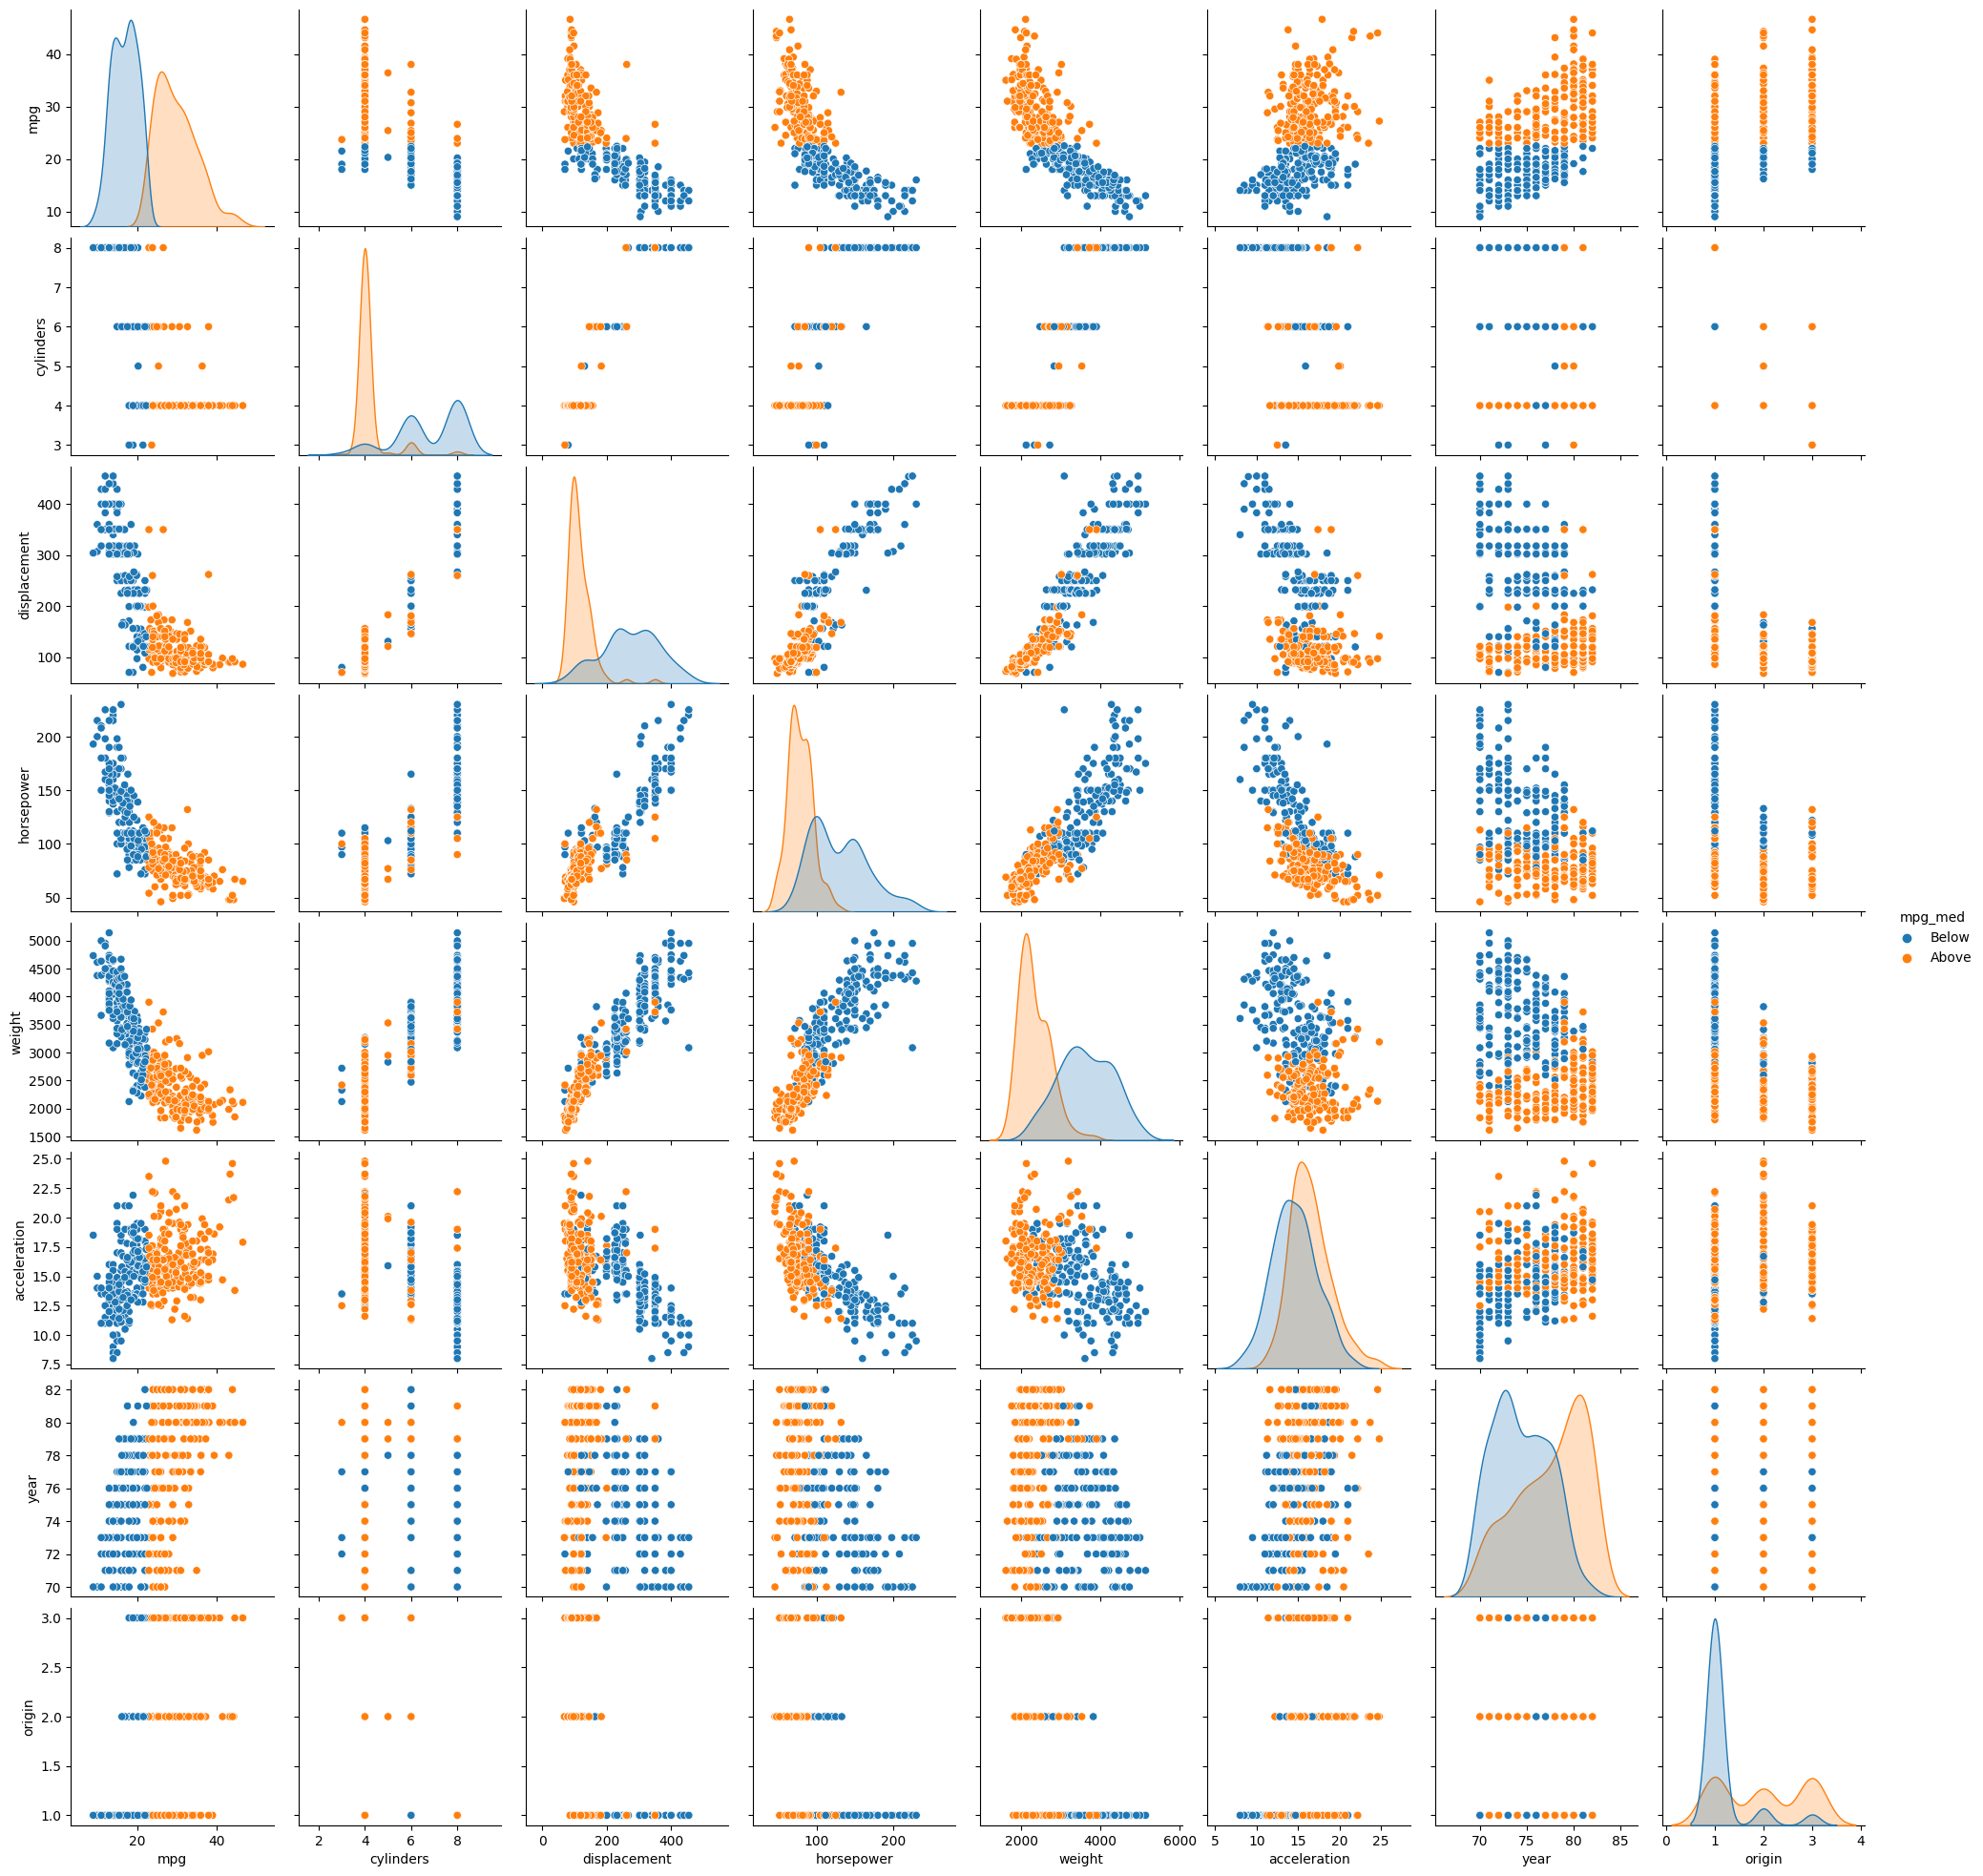

In [25]:
sns.pairplot(Auto, hue = "mpg_med");

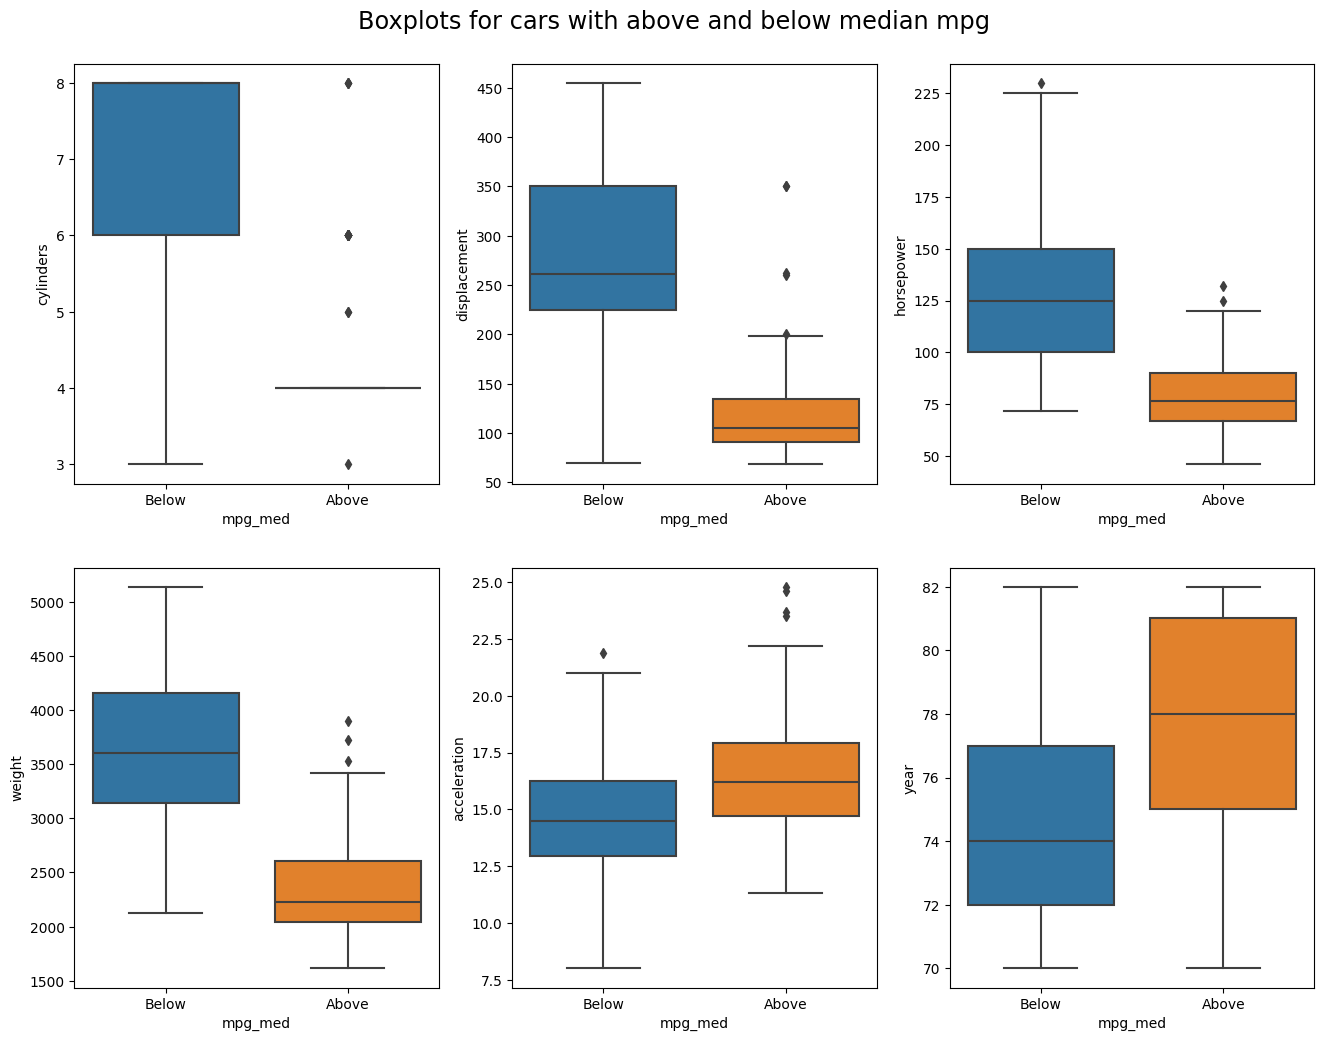

In [26]:
fig, axes=plt.subplots(nrows=2, ncols=3,figsize=(16,12))
#sns.boxplot?
sns.boxplot(x='mpg_med',y='cylinders',data=Auto,ax=axes[0,0])
sns.boxplot(x='mpg_med',y='displacement',data=Auto,ax=axes[0,1])
sns.boxplot(x='mpg_med',y='horsepower',data=Auto,ax=axes[0,2])
sns.boxplot(x='mpg_med',y='weight',data=Auto,ax=axes[1,0])
sns.boxplot(x='mpg_med',y='acceleration',data=Auto,ax=axes[1,1])
sns.boxplot(x='mpg_med',y='year',data=Auto,ax=axes[1,2])
fig.suptitle("Boxplots for cars with above and below median mpg",size = "xx-large", y = 0.925);
#displacement	horsepower	weight	acceleration	year


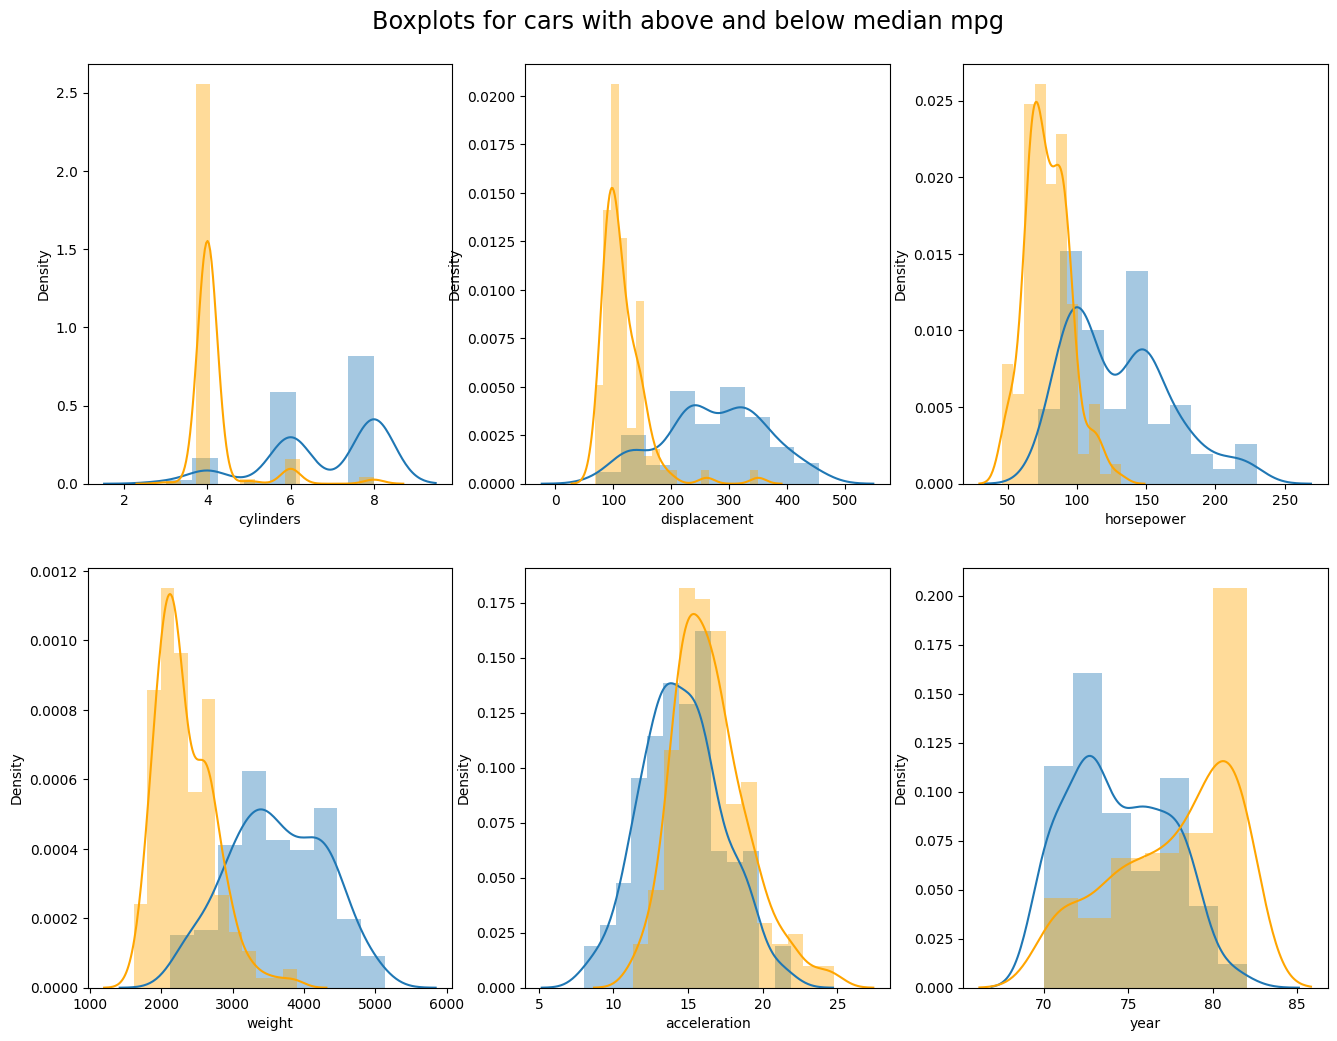

In [27]:
fig, axes=plt.subplots(nrows=2, ncols=3,figsize=(16,12))
# #sns.boxplot?
# sns.distplot(x='mpg_med',y='cylinders',data=Auto,ax=axes[0,0])
# sns.distplot(x='mpg_med',y='displacement',data=Auto,ax=axes[0,1])
# sns.distplot(x='mpg_med',y='horsepower',data=Auto,ax=axes[0,2])
# sns.distplot(x='mpg_med',y='weight',data=Auto,ax=axes[1,0])
# sns.distplot(x='mpg_med',y='acceleration',data=Auto,ax=axes[1,1])
# sns.distplot(x='mpg_med',y='year',data=Auto,ax=axes[1,2])
# fig.suptitle("Boxplots for cars with above and below median mpg",size = "xx-large", y = 0.925);
sns.distplot(Auto.loc[Auto["mpg_med"] == "Below", "cylinders"], ax = axes[0, 0])
sns.distplot(Auto.loc[Auto["mpg_med"] == "Above", "cylinders"], ax = axes[0, 0], color = "orange")
sns.distplot(Auto.loc[Auto["mpg_med"] == "Below", "displacement"], ax = axes[0, 1])
sns.distplot(Auto.loc[Auto["mpg_med"] == "Above", "displacement"], ax = axes[0, 1], color = "orange")
sns.distplot(Auto.loc[Auto["mpg_med"] == "Below", "horsepower"], ax = axes[0, 2])
sns.distplot(Auto.loc[Auto["mpg_med"] == "Above", "horsepower"], ax = axes[0, 2], color = "orange")
sns.distplot(Auto.loc[Auto["mpg_med"] == "Below", "weight"], ax = axes[1, 0])
sns.distplot(Auto.loc[Auto["mpg_med"] == "Above", "weight"], ax = axes[1, 0], color = "orange")
sns.distplot(Auto.loc[Auto["mpg_med"] == "Below", "acceleration"], ax = axes[1, 1])
sns.distplot(Auto.loc[Auto["mpg_med"] == "Above", "acceleration"], ax = axes[1, 1], color = "orange")
sns.distplot(Auto.loc[Auto["mpg_med"] == "Below", "year"], ax = axes[1, 2])
sns.distplot(Auto.loc[Auto["mpg_med"] == "Above", "year"], ax = axes[1, 2], color = "orange")
fig.suptitle("Boxplots for cars with above and below median mpg",size = "xx-large", y = 0.925);

AttributeError: 'QuadContourSet' object has no attribute 'collections'

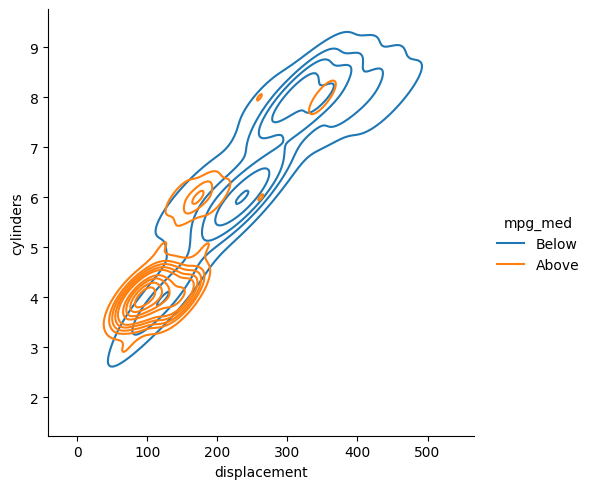

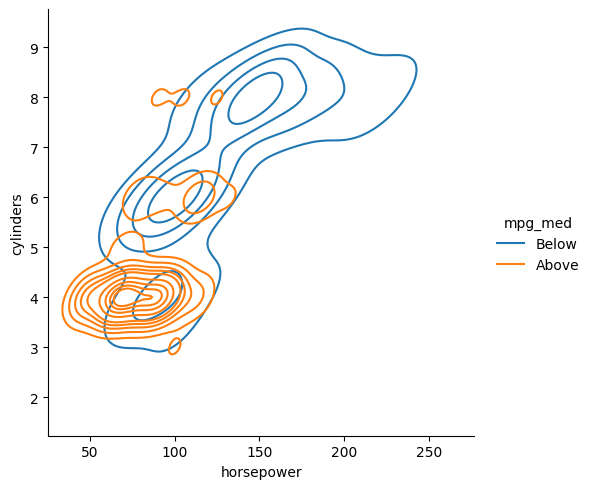

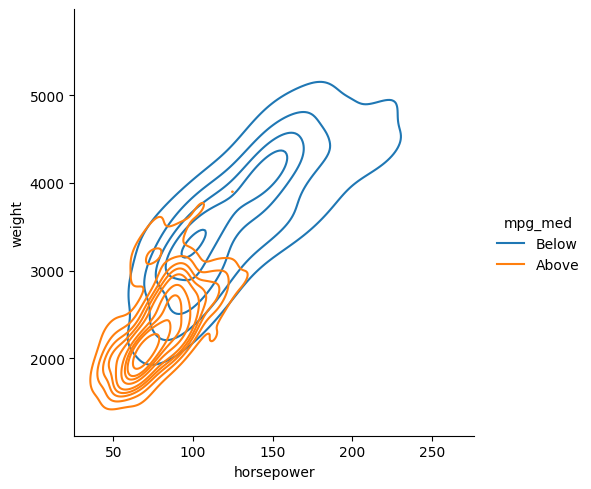

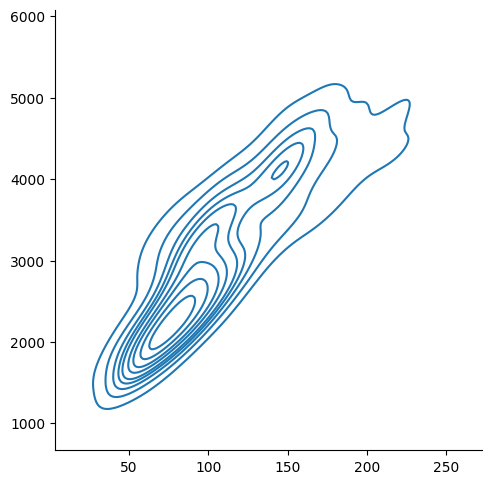

In [28]:
# Need better understanding to understand or dont know the right way to plot predictors
#sns.displot?
sns.displot(x='displacement', y='cylinders',data=Auto,hue='mpg_med',kind="kde")
sns.displot(x='horsepower', y='cylinders',data=Auto,hue='mpg_med',kind="kde")
sns.displot(x='horsepower', y='weight',data=Auto,hue='mpg_med',kind="kde")
sns.displot(x='horsepower', y='weight',data=Auto,kind="kde")

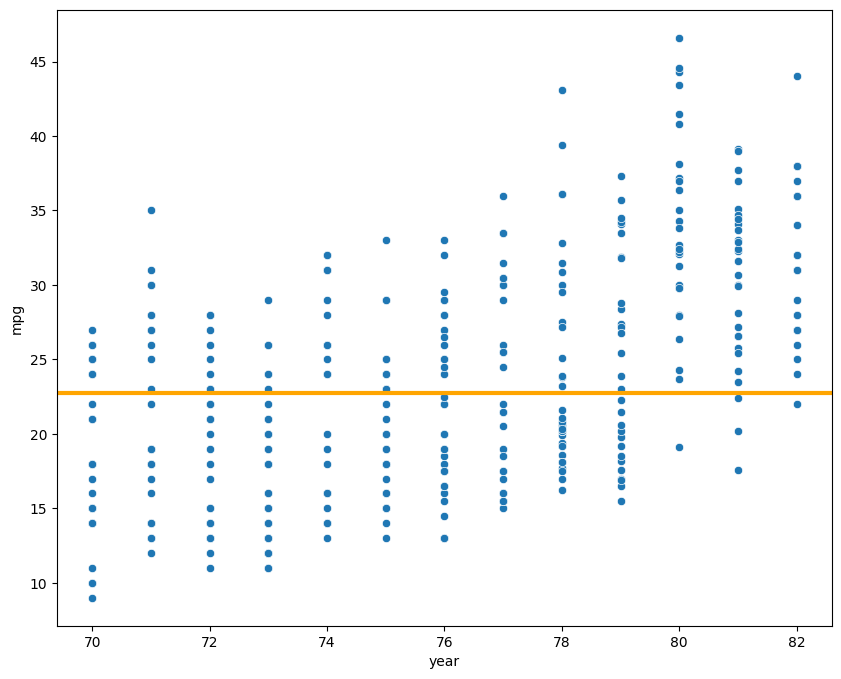

In [34]:
fig, ax = plt.subplots(figsize = (10, 8))
sns.scatterplot(x = "year", y = "mpg", data = Auto, ax = ax)
ax.axhline(y = Auto["mpg"].median(), color = "orange", linewidth = 3);

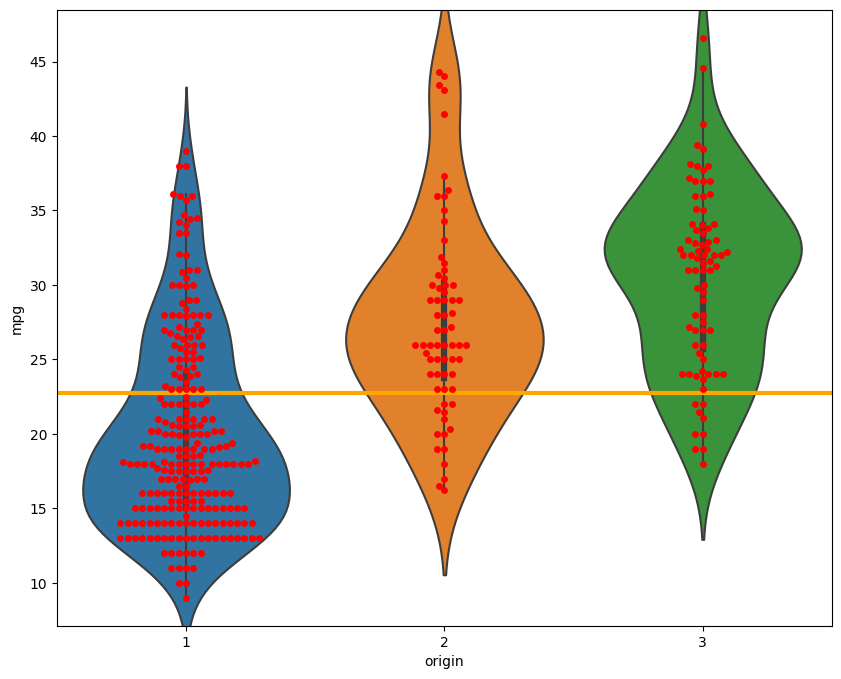

In [36]:
fig, ax = plt.subplots(figsize = (10, 8))
sns.violinplot(x = "origin", y = "mpg", data = Auto, ax = ax)
sns.swarmplot(x = "origin", y = "mpg", data = Auto, ax = ax,color='red')
#sns.violinplot(x = "origin", y = "mpg", data = Auto, ax = ax)
ax.axhline(y = Auto["mpg"].median(), color = "orange", linewidth = 3);

In [38]:
#train_test_split?
#mpg	cylinders	displacement	horsepower	weight	acceleration	year	origin	name
columns =['cylinders','displacement','horsepower','weight','year','origin']
Auto_Data=Auto[columns]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(Auto_Data, Auto["mpg_med"],random_state=312,test_size=0.25)

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [44]:
categorical_features = ["origin"]
categorical_transformer = Pipeline([("onehot", OneHotEncoder(drop = "first"))])
categorical_transformer
numerical_features = ["cylinders", "displacement", "horsepower", "weight", "year"]
preprocessor = ColumnTransformer([("cat", categorical_transformer, categorical_features),
                                 ("num", "passthrough", numerical_features)])
preprocessor
clf = Pipeline([("preprocessor", preprocessor), ("classifier", LDA())])
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['origin']),
                                                 ('num', 'passthrough',
                                                  ['cylinders', 'displacement',
                                                   'horsepower', 'weight',
                                                   'year'])])),
                ('classifier', LinearDiscriminantAnalysis())])

In [46]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
confusion_table(y_test, y_pred)

Truth,Above,Below
Predicted,,
Above,51,1
Below,9,37


In [48]:
# Test error
1-clf.score(X_test, y_test)

0.10204081632653061

In [50]:
#excluding origin and year

numerical_features = ["cylinders", "displacement", "horsepower", "weight"]
preprocessor = ColumnTransformer([("num", "passthrough", numerical_features)])
preprocessor
clf = Pipeline([("preprocessor", preprocessor), ("classifier", LDA())])
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['cylinders', 'displacement',
                                                   'horsepower', 'weight'])])),
                ('classifier', LinearDiscriminantAnalysis())])

In [52]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
confusion_table(y_test, y_pred)

Truth,Above,Below
Predicted,,
Above,50,2
Below,9,37


In [54]:
# Test error
1-clf.score(X_test, y_test)

0.11224489795918369

In [56]:
categorical_features = ["origin"]
categorical_transformer = Pipeline([("onehot", OneHotEncoder(drop = "first"))])
numerical_features = ["cylinders", "displacement", "horsepower", "weight", "year"]
preprocessor = ColumnTransformer([("cat", categorical_transformer, categorical_features),
                                 ("num", "passthrough", numerical_features)])
clf = Pipeline([("preprocessor", preprocessor), ("classifier", QDA())])
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['origin']),
                                                 ('num', 'passthrough',
                                                  ['cylinders', 'displacement',
                                                   'horsepower', 'weight',
                                                   'year'])])),
                ('classifier', QuadraticDiscriminantAnalysis())])

In [58]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
confusion_table(y_test, y_pred)

Truth,Above,Below
Predicted,,
Above,50,2
Below,7,39


In [60]:
# Test error
1-clf.score(X_test, y_test)

0.09183673469387754

In [62]:
#excluding origin and year in QDA
numerical_features = ["cylinders", "displacement", "horsepower", "weight"]
preprocessor = ColumnTransformer([("num", "passthrough", numerical_features)])
clf = Pipeline([("preprocessor", preprocessor), ("classifier", QDA())])
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['cylinders', 'displacement',
                                                   'horsepower', 'weight'])])),
                ('classifier', QuadraticDiscriminantAnalysis())])

In [64]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
confusion_table(y_test, y_pred)

Truth,Above,Below
Predicted,,
Above,50,2
Below,8,38


In [66]:
# Test error
1-clf.score(X_test, y_test)

0.10204081632653061

In [68]:

categorical_features = ["origin"]
categorical_transformer = Pipeline([("onehot", OneHotEncoder(drop = "first"))])
categorical_transformer
numerical_features = ["cylinders", "displacement", "horsepower", "weight", "year"]
preprocessor = ColumnTransformer([("cat", categorical_transformer, categorical_features),
                                 ("num", "passthrough", numerical_features)])
preprocessor
clf = Pipeline([("preprocessor", preprocessor), ("classifier", LogisticRegression(solver = "lbfgs", max_iter = 10000))])
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['origin']),
                                                 ('num', 'passthrough',
                                                  ['cylinders', 'displacement',
                                                   'horsepower', 'weight',
                                                   'year'])])),
                ('classifier', LogisticRegression(max_iter=10000))])

In [70]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
confusion_table(y_test, y_pred)

Truth,Above,Below
Predicted,,
Above,46,6
Below,7,39


In [72]:
1-clf.score(X_test, y_test)

0.13265306122448983

In [74]:
#excluding origin and year in QDA
numerical_features = ["cylinders", "displacement", "horsepower", "weight"]
preprocessor = ColumnTransformer([("num", "passthrough", numerical_features)])
clf = Pipeline([("preprocessor", preprocessor), ("classifier", LogisticRegression(solver = "lbfgs", max_iter = 10000))])
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['cylinders', 'displacement',
                                                   'horsepower', 'weight'])])),
                ('classifier', LogisticRegression(max_iter=10000))])

In [76]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
confusion_table(y_test, y_pred)

Truth,Above,Below
Predicted,,
Above,50,2
Below,9,37


In [78]:
1-clf.score(X_test, y_test)

0.11224489795918369

In [80]:
#excluding origin and year in QDA
numerical_features = ["cylinders", "displacement", "horsepower", "weight"]
preprocessor = ColumnTransformer([("num", "passthrough", numerical_features)])
clf = Pipeline([("preprocessor", preprocessor), ("classifier", LogisticRegression(solver = "lbfgs", max_iter = 500))])
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['cylinders', 'displacement',
                                                   'horsepower', 'weight'])])),
                ('classifier', LogisticRegression(max_iter=500))])

In [82]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
confusion_table(y_test, y_pred)
1-clf.score(X_test, y_test)

0.11224489795918369

In [84]:
numerical_features = ["cylinders", "displacement", "horsepower", "weight", "year"]
numerical_transformer = Pipeline([("standardize", StandardScaler())])
preprocessor = ColumnTransformer([("num", numerical_transformer, numerical_features)])
np.random.seed(312)

k_vals = list(range(1, 21, 2))
knn_errors = {}
confusion_matrices = {}
for k in k_vals:
    clf = Pipeline([("preprocessor", preprocessor), ("classifier", KNeighborsClassifier(n_neighbors = k))])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    confusion_matrices[k] = confusion_matrix(y_test, y_pred)
    knn_errors[k] = 1 - clf.score(X_test, y_test)
    
pd.Series(knn_errors)

1     0.081633
3     0.081633
5     0.081633
7     0.091837
9     0.091837
11    0.102041
13    0.081633
15    0.081633
17    0.081633
19    0.081633
dtype: float64

In [86]:
numerical_features = ["cylinders", "displacement", "horsepower", "weight"]
numerical_transformer = Pipeline([("standardize", StandardScaler())])
preprocessor = ColumnTransformer([("num", numerical_transformer, numerical_features)])
np.random.seed(312)

k_vals = list(range(1, 21, 2))
knn_errors = {}
confusion_matrices = {}
for k in k_vals:
    clf = Pipeline([("preprocessor", preprocessor), ("classifier", KNeighborsClassifier(n_neighbors = k))])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    confusion_matrices[k] = confusion_matrix(y_test, y_pred)
    knn_errors[k] = 1 - clf.score(X_test, y_test)
    
pd.Series(knn_errors)

1     0.112245
3     0.102041
5     0.112245
7     0.102041
9     0.091837
11    0.091837
13    0.091837
15    0.091837
17    0.091837
19    0.091837
dtype: float64

In [88]:
def Power(x,a):
    return x**a

In [90]:
print(Power(2,3))

8


In [92]:
print(Power(3,8))

6561


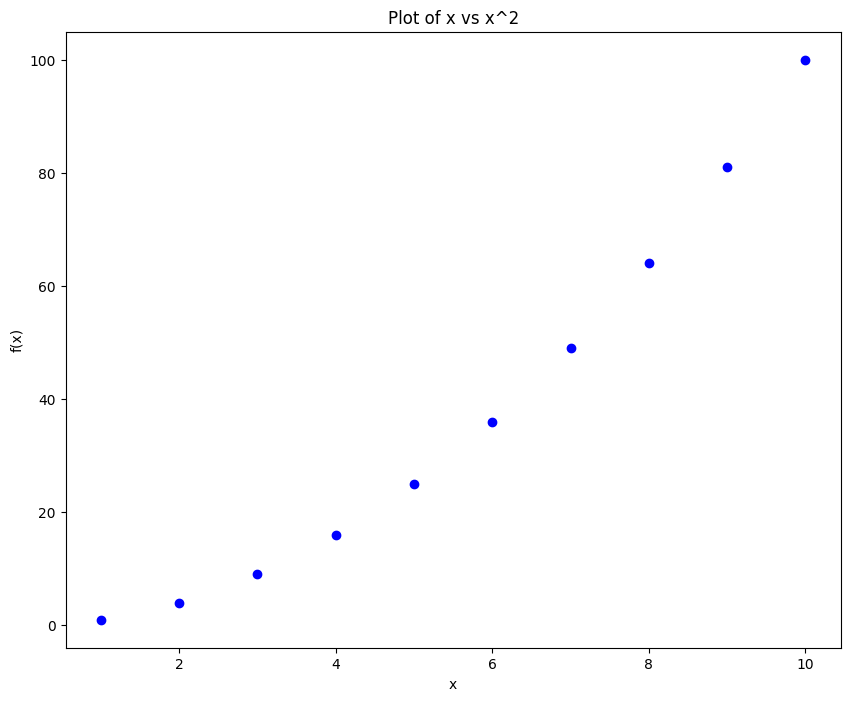

In [94]:
x = list(range(1, 11))
#y = list(Power(a,2) for a in x)
y = [Power(a,2) for a in x]
fig, ax = plt.subplots(figsize = (10, 8))
ax.plot(x, y, "bo")
ax.set(xlabel = "x", ylabel = "f(x)", title = "Plot of x vs x^2");


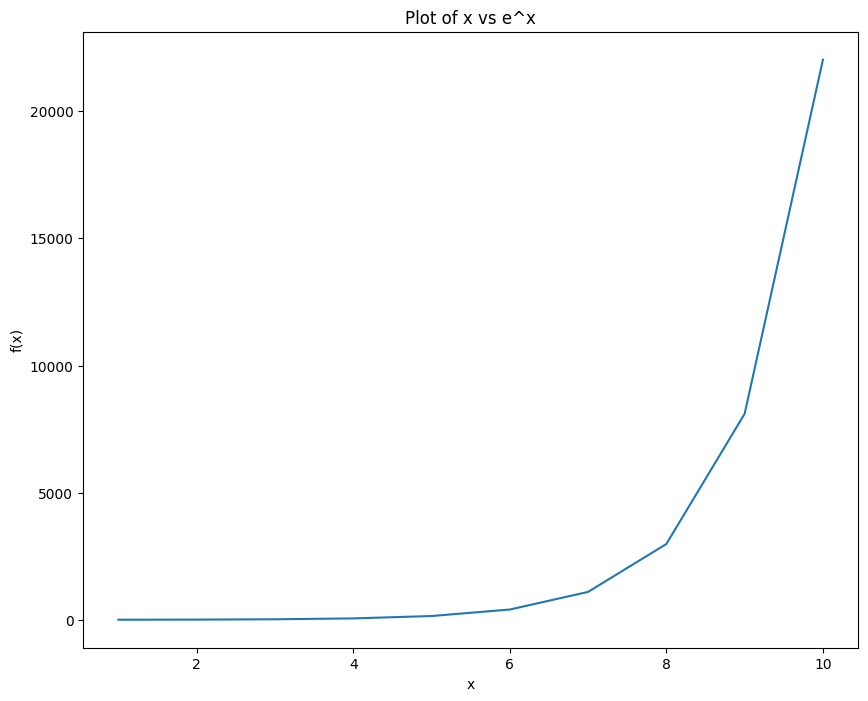

In [96]:
x = list(range(1, 11))
#y = list(Power(a,2) for a in x)
y = [np.exp(a) for a in x]
fig, ax = plt.subplots(figsize = (10, 8))
ax.plot(x, y)
ax.set(xlabel = "x", ylabel = "f(x)", title = "Plot of x vs e^x");

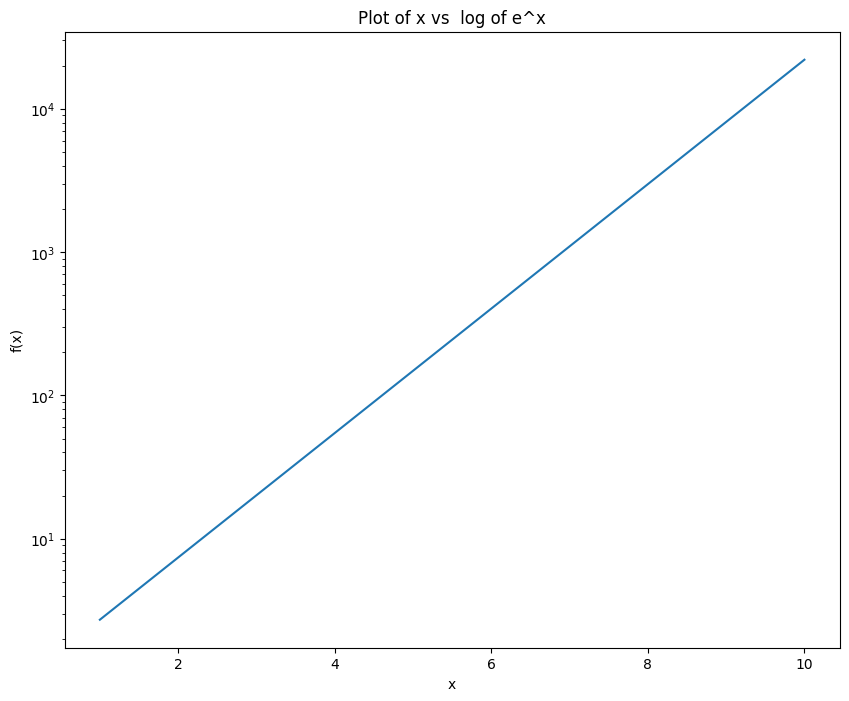

In [98]:
x = list(range(1, 11))
#y = list(Power(a,2) for a in x)
y = [np.exp(a) for a in x]
fig, ax = plt.subplots(figsize = (10, 8))
ax.semilogy(x, y)
# which is nothing but straight line
ax.set(xlabel = "x", ylabel = "f(x)", title = "Plot of x vs  log of e^x");

In [100]:
def PlotPower(x, a, x_scale = None, y_scale = None):
    """
    Assumes x is array-like, a is a float
    If given, assumes x_scale, y_scale are strings that can be passed to the
    matplotlib Axes.set_xscale() and Axes.set_yscale() functions
    """
    y = [Power(i, a) for i in x]
    fig, ax = plt.subplots(figsize = (10, 8))
    ax.plot(x, y, "bo")
    if x_scale is not None:
        ax.set_xscale(x_scale)
    if y_scale is not None:
        ax.set_yscale(y_scale)

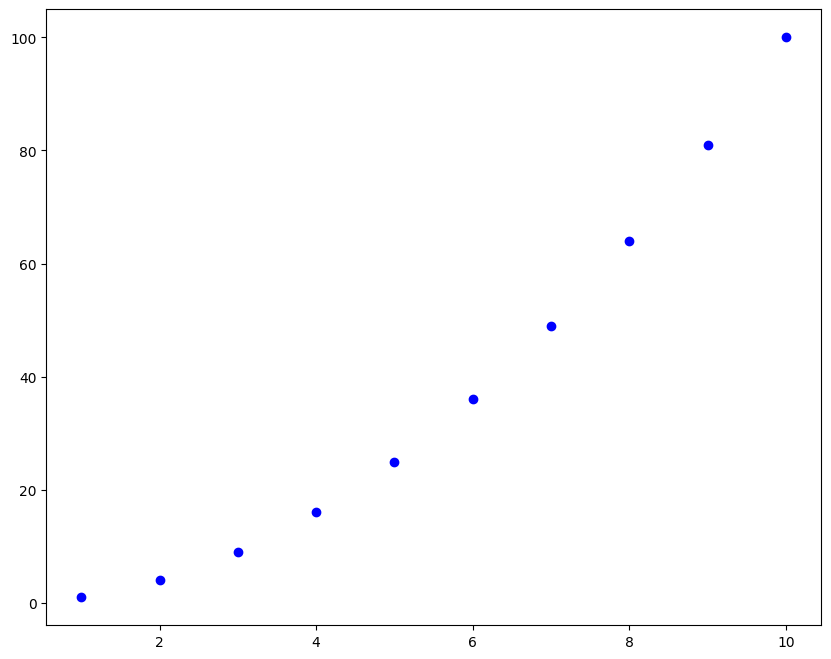

In [102]:
PlotPower(np.arange(1, 11),2)

In [104]:
Boston = load_data('Boston')
Boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


In [106]:
Boston['crim'].median()

0.25651

In [108]:
Boston['crim_med']=(Boston['crim']>Boston['crim'].median()).map({True:"Above",False:"Below"})
Boston['crim_med'].value_counts()

crim_med
Below    253
Above    253
Name: count, dtype: int64

In [115]:
#Boston.corr()['crim']

In [ ]:
# Based on above  Corr we found indus ,nox ,age ,dis , rad,tax,lstat ,medv
#sns.pairplot(Boston, hue = "crim_med");


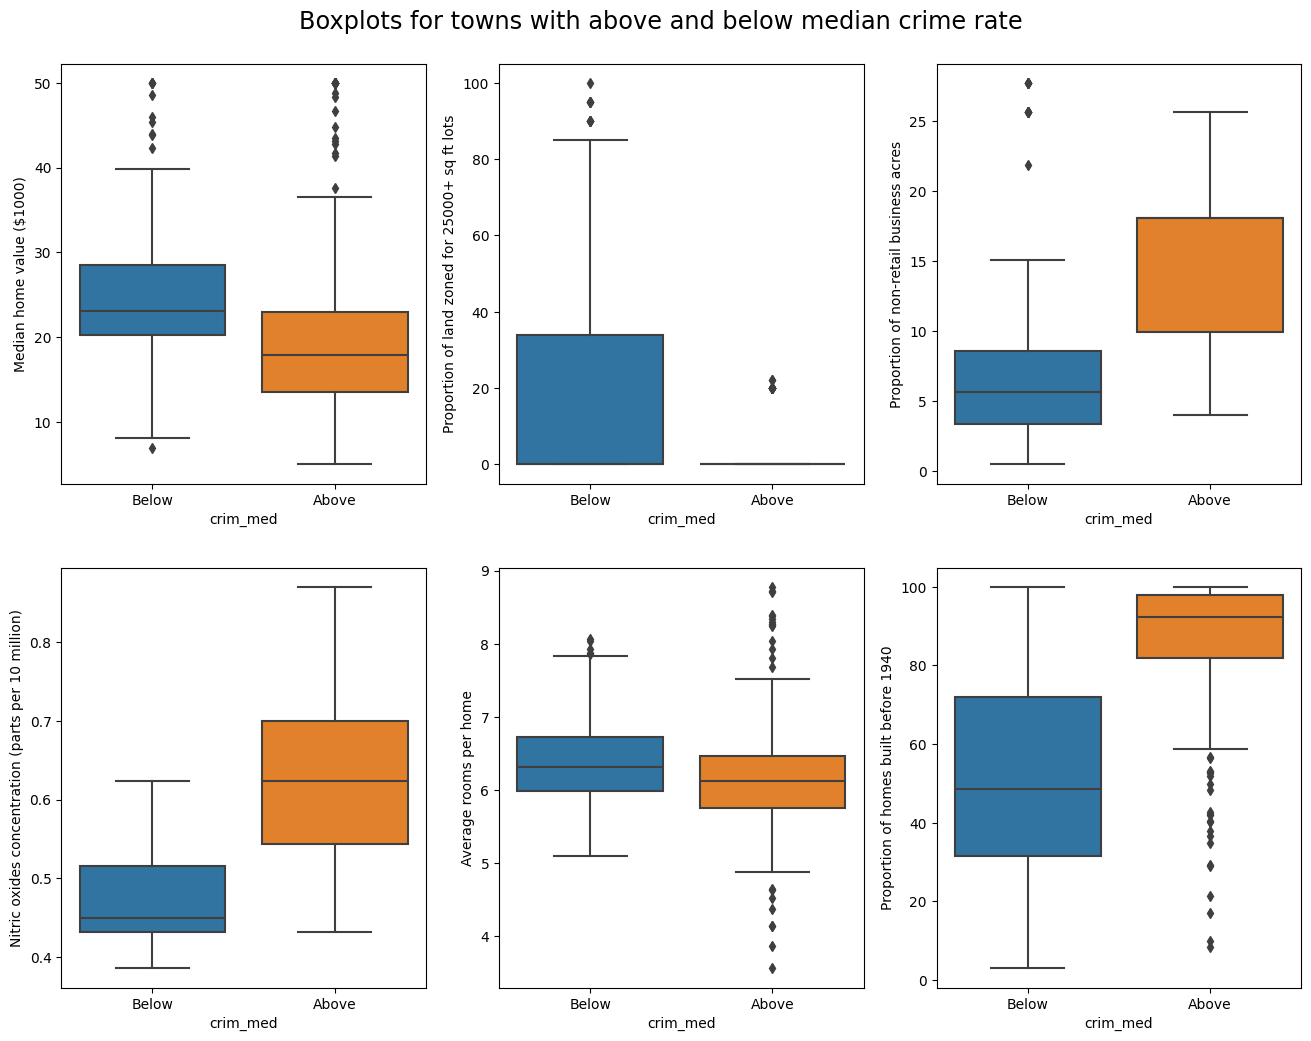

In [117]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (16, 12))
sns.boxplot(x = "crim_med", y = "medv", data = Boston, ax = axes[0, 0])
axes[0, 0].set_ylabel("Median home value ($1000)")
sns.boxplot(x = "crim_med", y = "zn", data = Boston, ax = axes[0, 1])
axes[0, 1].set_ylabel("Proportion of land zoned for 25000+ sq ft lots")
sns.boxplot(x = "crim_med", y = "indus", data = Boston, ax = axes[0, 2])
axes[0, 2].set_ylabel("Proportion of non-retail business acres")
sns.boxplot(x = "crim_med", y = "nox", data = Boston, ax = axes[1, 0])
axes[1, 0].set_ylabel("Nitric oxides concentration (parts per 10 million)")
sns.boxplot(x = "crim_med", y = "rm", data = Boston, ax = axes[1, 1])
axes[1, 1].set_ylabel("Average rooms per home")
sns.boxplot(x = "crim_med", y = "age", data = Boston, ax = axes[1, 2])
axes[1, 2].set_ylabel("Proportion of homes built before 1940")
fig.suptitle("Boxplots for towns with above and below median crime rate", size = "xx-large", y = 0.925);

In [119]:
#https://www.kaggle.com/code/suugaku/islr-chapter-4-applied-exercises-python/notebook